<a href="https://colab.research.google.com/github/yoh6ly/Yohaly/blob/main/taller_mlp_xor_desde_cero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

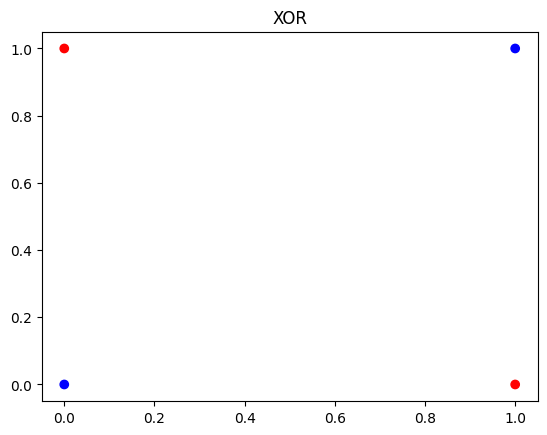

Acc lineal: 0.5


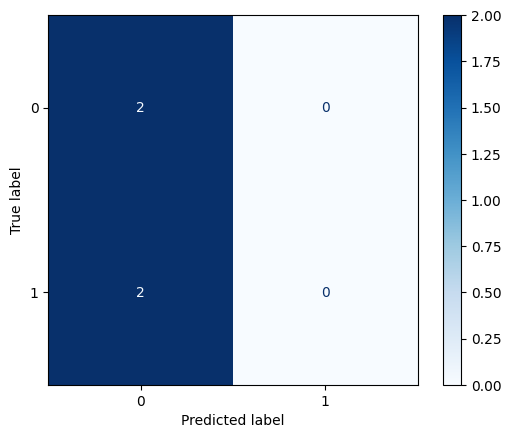

Acc MLP: 0.5


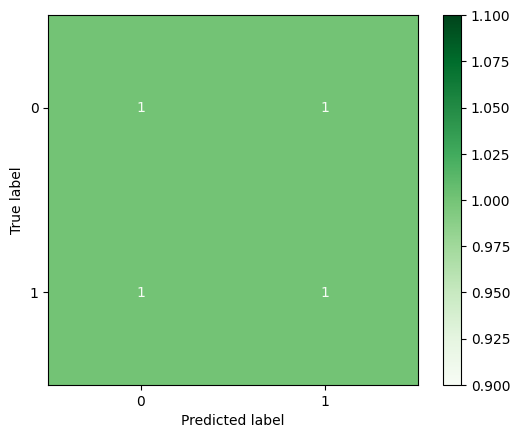

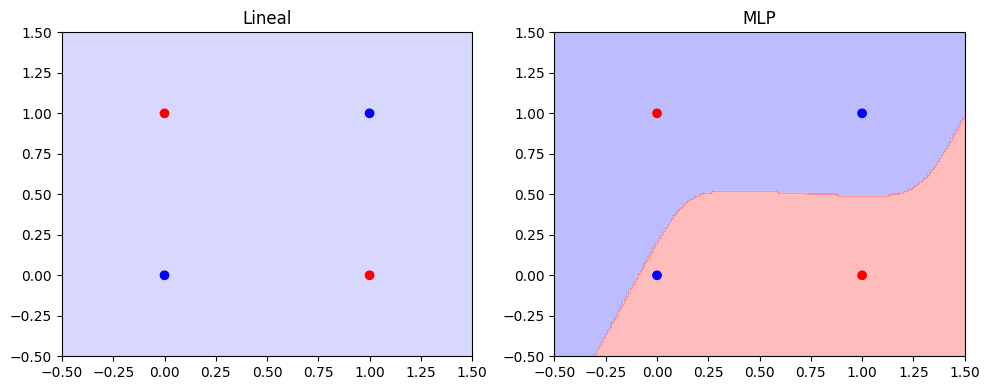

Conclusión: El perceptrón lineal no logra separar el problema XOR, porque es linealmente inseparable. En cambio, el MLP con una capa oculta y activación no lineal sí aprende la frontera correcta, mostrando la ventaja de las redes neuronales frente a modelos lineales en problemas no lineales.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

np.random.seed(42)

# 3) Crear el dataset XOR y visualizar
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([0,1,1,0], dtype=int)
plt.figure()
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.title('XOR')
plt.show()

# 4) Baseline lineal: Perceptrón/SGDClassifier y evaluación
clf_lin = SGDClassifier(loss='perceptron', max_iter=2000, tol=1e-3, random_state=42)
clf_lin.fit(X, y)
yhat_lin = clf_lin.predict(X)
print('Acc lineal:', accuracy_score(y, yhat_lin))
ConfusionMatrixDisplay.from_predictions(y, yhat_lin, cmap='Blues')
plt.show()

# 5) MLP mínimo con una capa oculta y activación no lineal
mlp = MLPClassifier(hidden_layer_sizes=(2,), activation='tanh', solver='lbfgs',
                    max_iter=5000, random_state=42)
mlp.fit(X, y)
yhat_mlp = mlp.predict(X)
print('Acc MLP:', accuracy_score(y, yhat_mlp))
ConfusionMatrixDisplay.from_predictions(y, yhat_mlp, cmap='Greens')
plt.show()

# 6) Fronteras de decisión para ambos modelos
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,200), np.linspace(-0.5,1.5,200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz_lin = clf_lin.predict(grid).reshape(xx.shape)
zz_mlp = mlp.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].contourf(xx, yy, zz_lin, alpha=0.3, cmap='bwr')
ax[0].scatter(X[:,0], X[:,1], c=y, cmap='bwr')
ax[0].set_title('Lineal')

ax[1].contourf(xx, yy, zz_mlp, alpha=0.3, cmap='bwr')
ax[1].scatter(X[:,0], X[:,1], c=y, cmap='bwr')
ax[1].set_title('MLP')

plt.tight_layout()
plt.show()

# 7) Conclusión
print("Conclusión: El perceptrón lineal no logra separar el problema XOR, "
      "porque es linealmente inseparable. En cambio, el MLP con una capa oculta "
      "y activación no lineal sí aprende la frontera correcta, mostrando la "
      "ventaja de las redes neuronales frente a modelos lineales en problemas no lineales.")
